<img src="logo-UNSAM.png" style="float: right;" width="300" alt="Logo">

# <center>Análisis y Procesamiento de Señales</center>
<hr>

## <center>**TS7**: "Filtrado digital lineal de ECG"</center>

<br><br>

### <center>1er Cuatrimestre - 2026</center>
### <center>**Alumno:** D'Alesio Alejo</center>


<br>

En este trabajo vamos a analizar un registro electrocardiográfico (ECG) registrado durante una prueba de esfuerzo que contiene fuentes de contaminación como:
* Ruido causado por el movimiento de los electrodos (Alta frecuencia)
* Ruido muscular (Alta frecuencia)
* Movimiento de la línea de base del ECG, inducido en parte por la respiración (Baja frecuencia) 

El objetivo del trabajo sera diseñar y aplicar los filtros necesarios para mitigar dichas fuentes de contaminación.

## Filtros IIR

Para el diseño de la plantilla del filtro digital, se deben especificar dos frecuencias de paso (wp1, wp2), dos frecuencias de stop (ws1, ws2), la atenuación máxima en banda de paso (gpass) y la atenuación mínima en banda de stop (gstop).
A partir del análisis espectral (PSD) de la señal de ECG, se observó que la energía útil de la señal se concentra entre wp1 = 0.5 Hz y wp2 = 35 Hz.
La frecuencia de stop inferior la fijamos en ws1 = 0.1 Hz.
La frecuencia de stop superior la fijamos en ws2 = 45 Hz.
La atenuación en banda de paso, por dato, se fija en gpass = 1 dB. La atenuación mínima en banda de stop se fija en gstop = 40 dB, lo que significa reducir el ruido a 1/100 de su amplitud original, suficiente dado el nivel de ruido observado en el espectro de la señal.

Vamos a diseñar tres filtros digitales IIR adoptando las aproximaciones de modulo de maxima planicidad, Chebyshev y Cauer

C:\Users\aleej\AppData\Local\Temp\ipykernel_13620\2342513910.py:47: RuntimeWarning: divide by zero encountered in log10
  db_butter = 20 * np.log10(np.abs(h_butter))


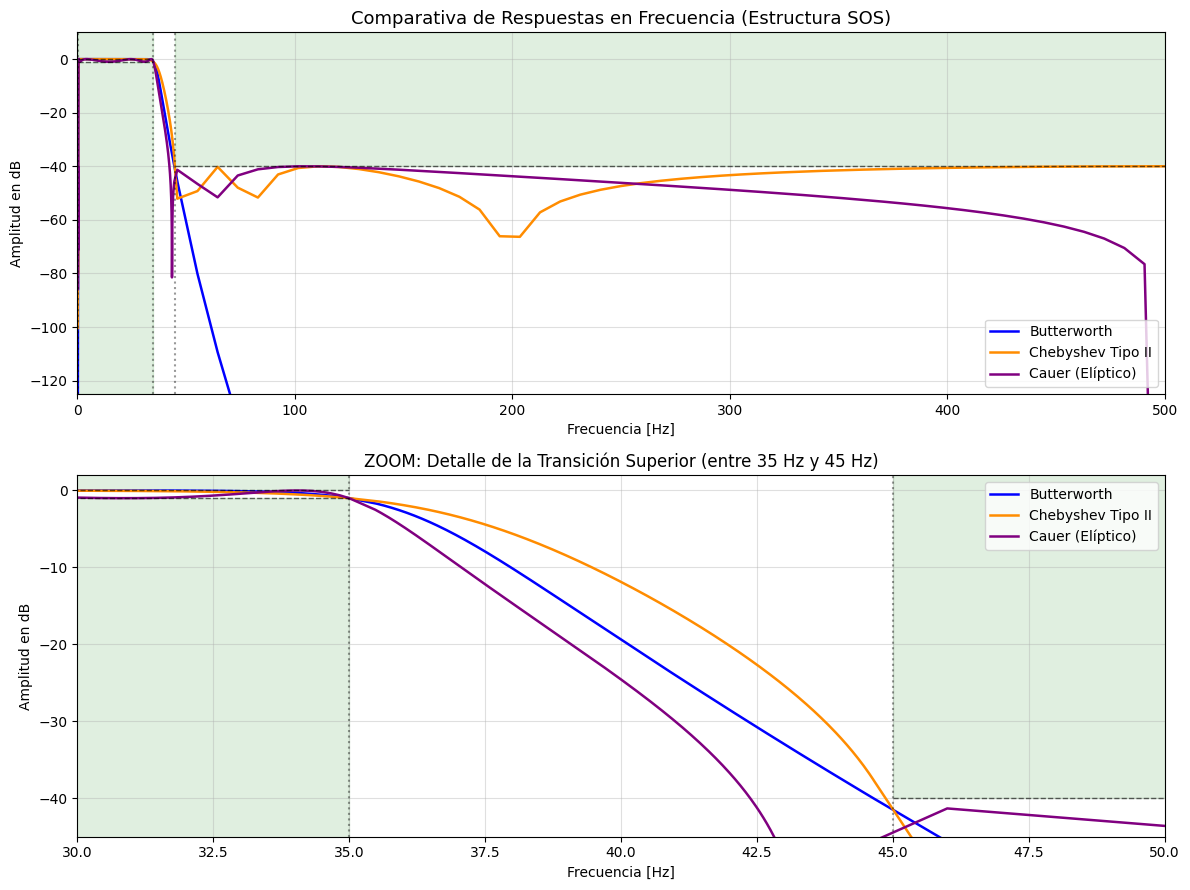

In [15]:
"""
@author: alejo
"""

#%% Librerías
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import signal as sig
import scipy.io as sio

#%%  Módulo en veces y Fase desenvuelta
fs = 1000      # Frecuencia de muestreo en Hz

gpass = 1     # Atenuación máxima permitida en banda de paso (dB)
gstop = 40    # Atenuación mínima requerida en banda de stop (dB)

# Para un filtro pasa banda (diseno de plantilla)
ws1 = 0.1
wp1 = 0.5 
ws2 = 45
wp2 = 35

wp = [wp1, wp2]
ws = [ws1, ws2] 

###################################
####### GRILLA PERSONALIZADA #######
###################################
# Se usa np.concatenate para asegurar compatibilidad en entornos estándar
ww = np.concatenate([np.logspace(start = -2, stop = 0.1, num = 500), 
                     np.linspace(start = 1.26, stop = 35, num = 200), 
                     np.logspace(start = 1.55, stop = 1.65, num = 300),
                     np.linspace(start = 46, stop = fs//2, num = 50)])

# Respuesta en frecuencia - Diseños de los 3 filtros
sos_butter = sig.iirdesign(wp, ws, gpass, gstop, fs=fs, analog=False, ftype='butter', output='sos')
sos_cheby  = sig.iirdesign(wp, ws, gpass, gstop, fs=fs, analog=False, ftype='cheby2', output='sos')
sos_cauer  = sig.iirdesign(wp, ws, gpass, gstop, fs=fs, analog=False, ftype='cauer', output='sos')

# Evaluamos la respuesta en frecuencia para cada uno
w, h_butter = sig.sosfreqz(sos_butter, worN=ww, fs=fs)
_, h_cheby  = sig.sosfreqz(sos_cheby, worN=ww, fs=fs)
_, h_cauer  = sig.sosfreqz(sos_cauer, worN=ww, fs=fs)

# Convertimos las magnitudes a dB
db_butter = 20 * np.log10(np.abs(h_butter))
db_cheby  = 20 * np.log10(np.abs(h_cheby))
db_cauer  = 20 * np.log10(np.abs(h_cauer))

# =============================================================================
# BLOQUE DE PLOTS: VISTA GENERAL Y ZOOM SUPERIOR (3 FILTROS)
# =============================================================================
fig, (ax_main, ax_zoom) = plt.subplots(2, 1, figsize=(12, 9), tight_layout=True)

# Seteamos un piso y techo visuales para el gráfico
piso_grafico = -125
techo_grafico = 10

for ax in [ax_main, ax_zoom]:
    # 1. Graficar las tres curvas con distintos colores
    ax.plot(w, db_butter, color='blue', linewidth=1.8, label='Butterworth')
    ax.plot(w, db_cheby, color='darkorange', linewidth=1.8, label='Chebyshev Tipo II')
    ax.plot(w, db_cauer, color='purple', linewidth=1.8, label='Cauer (Elíptico)')
    
    # 2. Sombreado de la Plantilla (Zonas prohibidas)
    # --- Banda de parada 1 (0 a ws1) ---
    ax.fill_between([0, ws1], -gstop, techo_grafico, color='green', alpha=0.12)
    ax.plot([0, ws1], [-gstop, -gstop], 'k--', linewidth=1, alpha=0.6)
    
    # --- Banda de paso (wp1 a wp2) ---
    # Zona inferior
    ax.fill_between([wp1, wp2], piso_grafico, -gpass, color='green', alpha=0.12)
    ax.plot([wp1, wp2], [-gpass, -gpass], 'k--', linewidth=1, alpha=0.6)
    # Zona superior (Ajustada a 0 dB para coherencia matemática de filtros normalizados)
    ax.fill_between([wp1, wp2], 0, techo_grafico, color='green', alpha=0.12) 
    ax.plot([wp1, wp2], [0, 0], 'k--', linewidth=1, alpha=0.6)
    
    # --- Banda de parada 2 (ws2 a Nyquist) ---
    ax.fill_between([ws2, fs/2], -gstop, techo_grafico, color='green', alpha=0.12)
    ax.plot([ws2, fs/2], [-gstop, -gstop], 'k--', linewidth=1, alpha=0.6)
    
    # Líneas verticales indicadoras de frecuencias de corte
    for freq in [ws1, wp1, wp2, ws2]:
        ax.axvline(freq, color='k', linestyle=':', alpha=0.4)
        
    ax.grid(True, which='both', linestyle='-', alpha=0.4)

# =============================================================================
# CONFIGURACIÓN DE LÍMITES Y EJES INDIVIDUALES
# =============================================================================

# Configuración del Gráfico General (Arriba)
ax_main.set_title("Comparativa de Respuestas en Frecuencia (Estructura SOS)", fontsize=13)
ax_main.set_ylabel('Amplitud en dB')
ax_main.set_xlabel('Frecuencia [Hz]')
ax_main.set_xlim(0, fs/2)
ax_main.set_ylim([piso_grafico, techo_grafico])
ax_main.legend(loc='lower right')

# Configuración del Zoom de Alta Frecuencia (Abajo: wp2 a ws2)
ax_zoom.set_title(f"ZOOM: Detalle de la Transición Superior (entre {wp2} Hz y {ws2} Hz)", fontsize=12)
ax_zoom.set_ylabel('Amplitud en dB')
ax_zoom.set_xlabel('Frecuencia [Hz]')

# Ajustamos los límites para ver la caída desde 0dB hasta cruzar los -40dB (gstop)
ax_zoom.set_xlim(30, 50)
ax_zoom.set_ylim([-45, 2]) 
ax_zoom.legend(loc='upper right')

plt.show()

In [16]:

orden_butt, _  = sig.buttord(wp, ws, gpass, gstop, fs=fs)
orden_cheby, _ = sig.cheb2ord(wp, ws, gpass, gstop, fs=fs)
orden_cauer, _ = sig.ellipord(wp, ws, gpass, gstop, fs=fs)

print(f"Orden real Butterworth:  {2*orden_butt}  (Secciones SOS: {sos_butter.shape[0]})")
print(f"Orden real Chebyshev II: {2*orden_cheby}  (Secciones SOS: {sos_cheby.shape[0]})")
print(f"Orden real Cauer:        {2*orden_cauer}  (Secciones SOS: {sos_cauer.shape[0]})")

Orden real Butterworth:  42  (Secciones SOS: 21)
Orden real Chebyshev II: 16  (Secciones SOS: 8)
Orden real Cauer:        10  (Secciones SOS: 5)


Observamos que los tres filtros IIR cumplen con los limites impuestos por la plantilla de diseño, tanto en la banda de paso como en las bandas de stop. Para el caso de Butterworth, vemos que es el de mayor orden, lo que obliga a usar mas polos para alcanzar la atenuación requerida en la banda de stop. Esto se traduce en mayor complejidad computacional. Luego, tenemos Chebyshev que tiene un orden intermedio, lo que da mas libertad para caer que el Butterworth con menos polos. Por último, tenemos el caso del Cauer que tiene el menor orden, siendo el que tiene menor complejidad computacional. 

Ahora, analizamos y procesamos la señal del ECG con ruido utilizando los filtros que diseñamos.

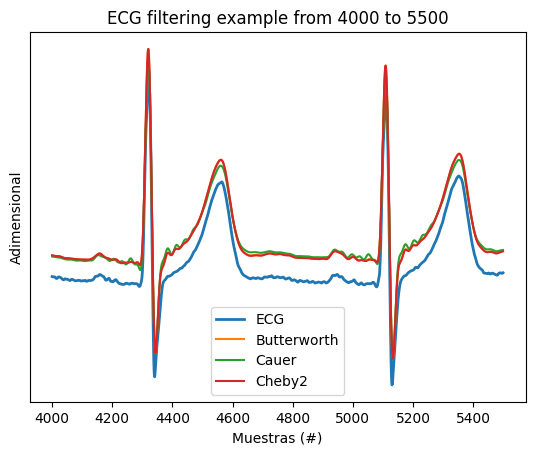

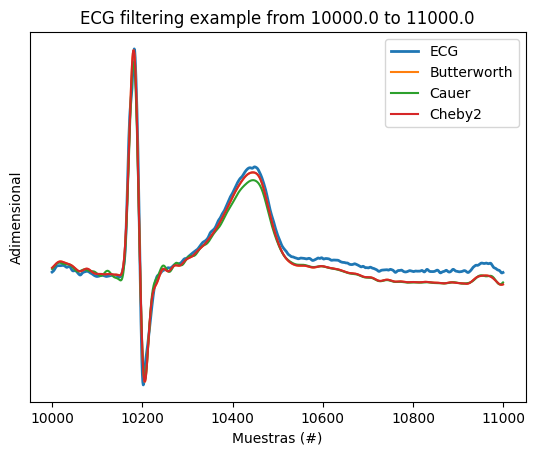

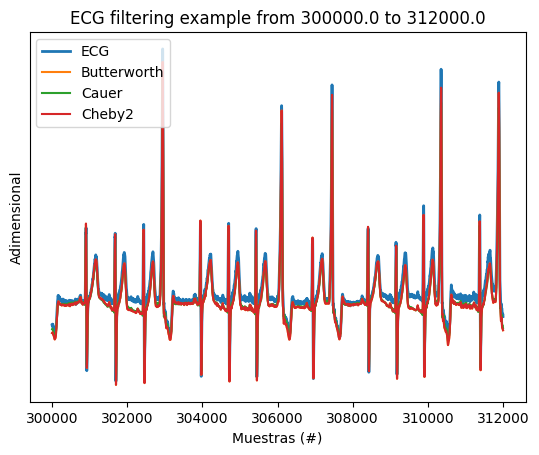

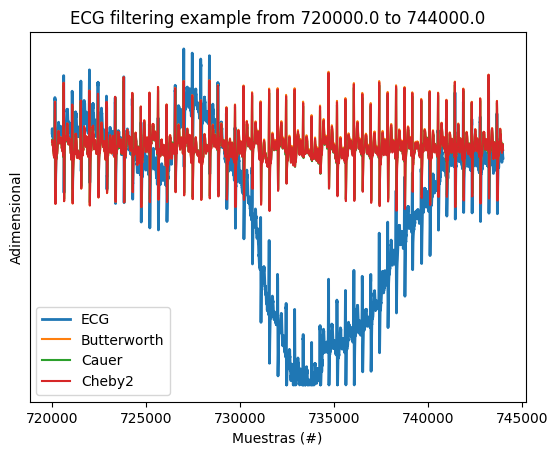

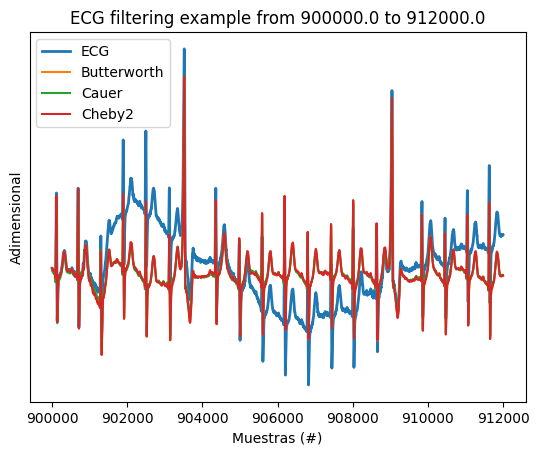

In [17]:
#uso filtfilt entonces divido por dos gpass y gstop 

sos_ff_butter = sig.iirdesign(wp, ws, gpass/2, gstop/2, fs=fs, analog=False, ftype='butter', output='sos')
sos_ff_cheby  = sig.iirdesign(wp, ws, gpass/2, gstop/2, fs=fs, analog=False, ftype='cheby2', output='sos')
sos_ff_cauer  = sig.iirdesign(wp, ws, gpass/2, gstop/2, fs=fs, analog=False, ftype='cauer', output='sos')

mat_struct = sio.loadmat(r'pdstestbench/ECG_TP4.mat')

ecg_one_lead = mat_struct['ecg_lead'].flatten() #lo aplanamos
cant_muestras = len(ecg_one_lead)

#Procesar ecg

ECG_f_butt = sig.sosfiltfilt(sos_ff_butter, ecg_one_lead)
ECG_f_cauer = sig.sosfiltfilt(sos_ff_cauer, ecg_one_lead)
ECG_f_cheby2 = sig.sosfiltfilt(sos_ff_cheby, ecg_one_lead)

###################################
#%% Regiones de interés sin ruido #
###################################
 
regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth')
    plt.plot(zoom_region, ECG_f_cauer[zoom_region], label='Cauer')
    plt.plot(zoom_region, ECG_f_cheby2[zoom_region], label='Cheby2')
    #plt.plot(zoom_region, ECG_f_win[zoom_region + demora], label='FIR Window')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()
 
###################################
#%% Regiones de interés con ruido #
###################################
 
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth')
    plt.plot(zoom_region, ECG_f_cauer[zoom_region], label='Cauer')
    plt.plot(zoom_region, ECG_f_cheby2[zoom_region], label='Cheby2')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()

Al aplicar los filtros mediante sosfiltfilt se observa que los tres diseños logran reducir el ruido de alta frecuencia mejorando la suavidad de los trazos, cumpliendo así con los objetivos planteados en el diseño de la plantilla. Asimismo, se destaca la excelente capacidad de los tres diseños para eliminar la deriva de la línea de base visible en la señal original (entre las muestras 730.000 y 740.000). Al remover estas bajas frecuencias no deseadas, los filtros logran estabilizar y centrar la señal en el eje vertical sin distorsionar la morfología de los complejos QRS.

Considerando la relación entre calidad de filtrado y complejidad computacional, el filtro Cauer resulta el más conveniente: logra la misma calidad que el Butterworth con un orden menor, siendo por tanto más eficiente.

## Filtros FIR

Ahora vamos a diseñar los filtros FIR. Nos piden realizar al menos dos filtros FIR, voy a elegir diseñar el filtro FIR con metodologia de ventanas, con metodología de cuadrados mínimos y el filtro FIR de Parks-Mc Clellan-Remez. 

### Metodología de Ventanas

Para el caso del filtro FIR utilizando la metodología de ventanas, fui exigiendo la plantilla hasta obtener los parámetros que cumplan dicha plantilla, estos fueron $ ws1 = 0.1 Hz , ws2 = 42 Hz , wp1 = 2.6 Hz, wp2 = 37 Hz$ , utilizando una cantidad de numtaps = 2701

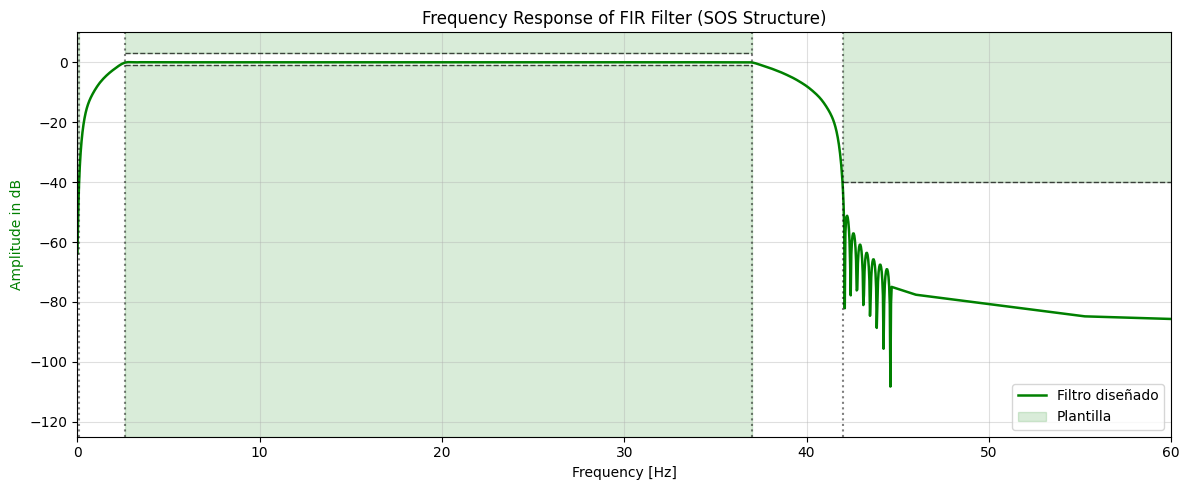

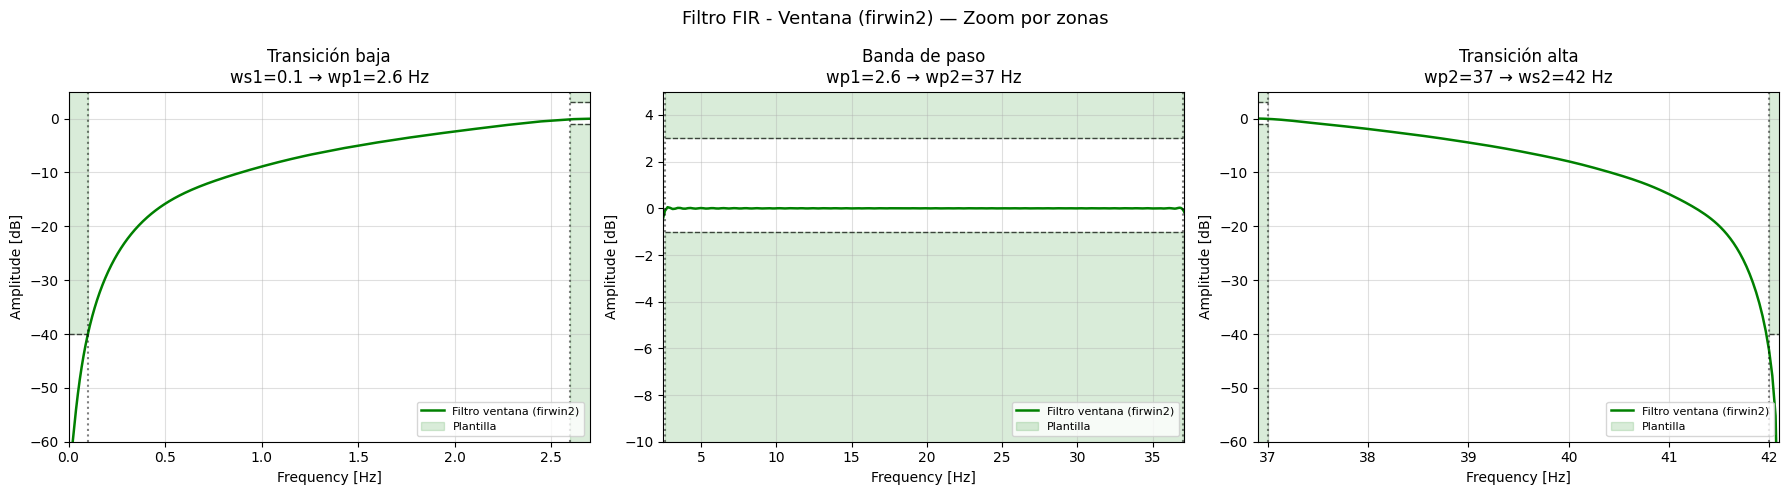

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import signal as sig
import scipy.io as sio

#%%  Módulo en veces y Fase desenvuelta
fs = 1000      # Frecuencia de muestreo en Hz

gpass = 1     # Atenuación máxima permitida en banda de paso (dB)
gstop = 40    # Atenuación mínima requerida en banda de stop (dB)

# Para un filtro pasa banda (diseno de plantilla)

ws1 = 0.1 
wp1 = 2.6 
ws2 = 42 
wp2 = 37

#en vez de 45 en 40

wp = [wp1, wp2]
ws = [ws1, ws2] 

###################################
#######GRILLA PERSONALIZADA########
###################################

ww = np.concat([np.logspace(start = -2,stop = 0.1, num = 500), 
               np.linspace(start=1.26,stop = 35, num = 200), 
               np.logspace(start = 1.55,stop = 1.65, num = 300),
               np.linspace(start= 46,stop = fs//2, num = 50)])

#%%------------------ DISEÑO DE FIRS--------------
#----VENTANAS-----

numtaps = 2701 #es tipo 2, cantidad de coef par, el retardo es no entero

demora = (numtaps - 1 ) //2 #division entera

gains = np.array([ 0, 0, 1, 1, 0, 0])


b_win = sig.firwin2(numtaps,freq=np.array([0.,ws1,wp1,wp2,ws2,fs//2]),
                            gain= gains,window = 'boxcar',
                            fs=fs)
w,h = sig.freqz(b_win,worN = ww, fs = fs)

#el tiempo con una cantidad de n muestras = numtaps =8000 seria una respuesta de 8 segundos
ceros,polos,k = sig.tf2zpk(b_win, a = 1)

#------------Filtro FIR (VENTANA)--------------------

fig, ax1 = plt.subplots(figsize=(12, 5), tight_layout=True)
ax1.set_title("Frequency Response of FIR Filter (SOS Structure)")

# 1. Dibujar la curva del filtro original (Magnitud en dB)
ax1.plot(w, 20 * np.log10(np.abs(h)), 'green', linewidth=1.8, label='Filtro diseñado')

# 2. Sombreado de la Plantilla (Zonas prohibidas / tolerancias)
# Piso y techo visual del gráfico para los rellenos
piso_grafico = -125
techo_grafico = 10

# --- Banda de parada 1 (0 a ws1) ---
ax1.fill_between([0, ws1], -gstop, techo_grafico, color='green', alpha=0.15, label='Plantilla')
ax1.plot([0, ws1], [-gstop, -gstop], 'k--', linewidth=1, alpha=0.7) # Línea de trazo límite

# --- Banda de paso (wp1 a wp2) ---
# Zona inferior (Atenuación máxima permitida)
ax1.fill_between([wp1, wp2], piso_grafico, -gpass, color='green', alpha=0.15)
ax1.plot([wp1, wp2], [-gpass, -gpass], 'k--', linewidth=1, alpha=0.7)
# Zona superior (Margen por encima de 0dB, ej: 3dB para evitar rizado excesivo)
ax1.fill_between([wp1, wp2], 3, techo_grafico, color='green', alpha=0.15)
ax1.plot([wp1, wp2], [3, 3], 'k--', linewidth=1, alpha=0.7)

# --- Banda de parada 2 (ws2 a Nyquist) ---
ax1.fill_between([ws2, fs/2], -gstop, techo_grafico, color='green', alpha=0.15)
ax1.plot([ws2, fs/2], [-gstop, -gstop], 'k--', linewidth=1, alpha=0.7)

# Líneas verticales que delimitan los saltos de las bandas
ax1.axvline(ws1, color='k', linestyle=':', alpha=0.5)
ax1.axvline(wp1, color='k', linestyle=':', alpha=0.5)
ax1.axvline(wp2, color='k', linestyle=':', alpha=0.5)
ax1.axvline(ws2, color='k', linestyle=':', alpha=0.5)

# 3. Configuración estricta de límites y estética
ax1.set_ylabel('Amplitude in dB', color='green')
ax1.set_xlabel('Frequency [Hz]')
ax1.set_xlim(0, 60)
ax1.set_ylim([piso_grafico, techo_grafico]) 

ax1.grid(True, which='both', linestyle='-', alpha=0.4)
ax1.legend(loc='lower right')

plt.show()

# =============================================================================
# BLOQUE DE PLOT - TRES SUBPLOTS CON ZOOM EN ZONAS DE INTERÉS (VENTANA)
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5), tight_layout=True)
fig.suptitle("Filtro FIR - Ventana (firwin2) — Zoom por zonas", fontsize=13)

margen = 0.1  # Hz

zonas = [
    (axes[0], (ws1 - margen, wp1 + margen), (-60,  5),   f"Transición baja\nws1={ws1} → wp1={wp1} Hz"),
    (axes[1], (wp1 - margen, wp2 + margen), (-10,  5),   f"Banda de paso\nwp1={wp1} → wp2={wp2} Hz"),
    (axes[2], (wp2 - margen, ws2 + margen), (-60,  5),   f"Transición alta\nwp2={wp2} → ws2={ws2} Hz"),
]

for ax, xlim, ylim, titulo in zonas:
    # Curva del filtro
    ax.plot(w, 20 * np.log10(np.abs(h)), 'green', linewidth=1.8, label='Filtro ventana (firwin2)')

    # --- Plantilla: banda de stop 1 ---
    ax.fill_between([0, ws1],      -gstop, techo_grafico, color='green', alpha=0.15, label='Plantilla')
    ax.plot(        [0, ws1],      [-gstop, -gstop],       'k--', linewidth=1, alpha=0.7)

    # --- Plantilla: banda de paso ---
    ax.fill_between([wp1, wp2], piso_grafico, -gpass,  color='green', alpha=0.15)
    ax.plot(        [wp1, wp2], [-gpass, -gpass],       'k--', linewidth=1, alpha=0.7)
    ax.fill_between([wp1, wp2], 3, techo_grafico,       color='green', alpha=0.15)
    ax.plot(        [wp1, wp2], [3, 3],                 'k--', linewidth=1, alpha=0.7)

    # --- Plantilla: banda de stop 2 ---
    ax.fill_between([ws2, fs/2],   -gstop, techo_grafico, color='green', alpha=0.15)
    ax.plot(        [ws2, fs/2],   [-gstop, -gstop],       'k--', linewidth=1, alpha=0.7)

    # Líneas verticales de referencia
    for xv in [ws1, wp1, wp2, ws2]:
        ax.axvline(xv, color='k', linestyle=':', alpha=0.5)

    # Zoom y estética
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(titulo)
    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel('Amplitude [dB]')
    ax.grid(True, which='both', linestyle='-', alpha=0.4)
    ax.legend(loc='lower right', fontsize=8)

plt.show()

Observamos que la respuesta en frecuencia del filtro diseñado satisface la plantilla especificada en todas las bandas, teniendo en cuenta que la atenuación en las bandas de stop supera los 40 dB y que tuvimos que utilizar una cantidad de numtaps bastante grande.

Ahora analizamos la señal del ECG utilizando este filtro.

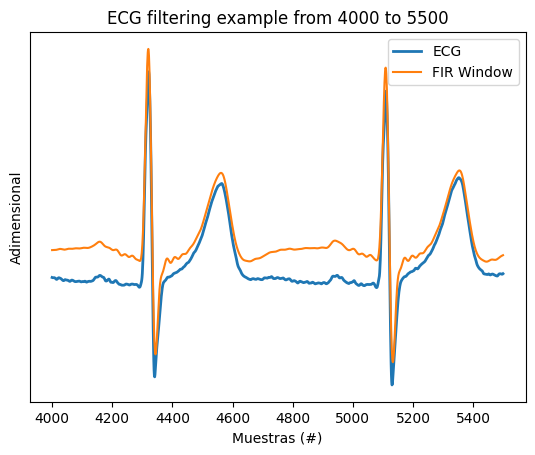

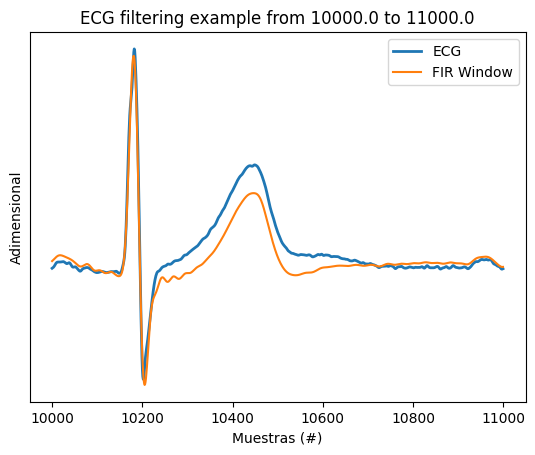

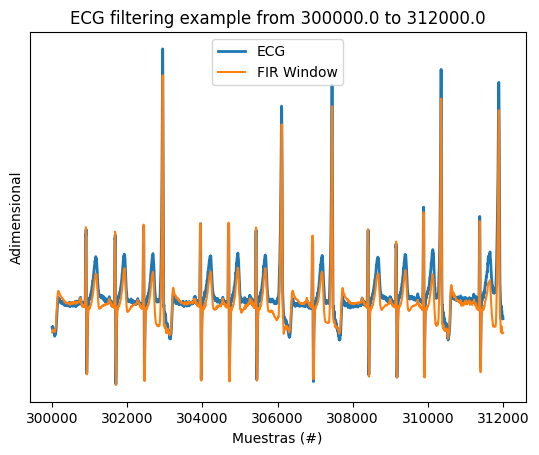

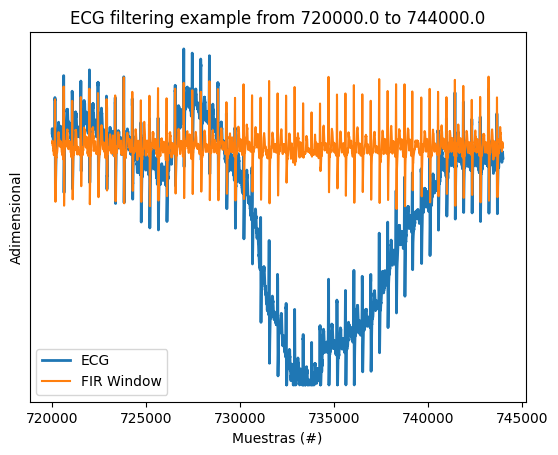

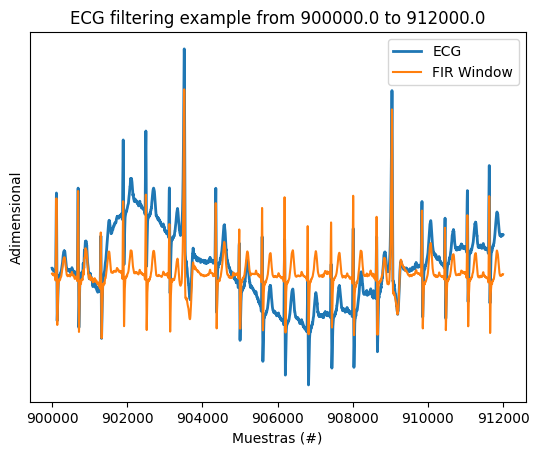

In [19]:
#%% PROCESAMIENTO DE SEÑAL DE ECG

##################
## ECG con ruido
##################
mat_struct = sio.loadmat(r'pdstestbench/ECG_TP4.mat')

ecg_one_lead = mat_struct['ecg_lead'].flatten() #lo aplanamos
cant_muestras = len(ecg_one_lead)

#Procesar ecg


ECG_f_win = sig.lfilter(b_win,1., ecg_one_lead)

###################################
#%% Regiones de interés sin ruido #
###################################
 
regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='int')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_win[zoom_region + demora], label='FIR Window')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()
 
###################################
#%% Regiones de interés con ruido #
###################################
 
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_win[zoom_region + demora], label='FIR Window')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()


Observamos que al procesar la señal de ECG se comprobó que el filtro preserva la morfología característica del complejo QRS, reduce la deriva de línea de base producida por componentes de muy baja frecuencia, y atenúa el ruido de alta frecuencia presente en la señal aunque no del todo. Es un filtro que necesito de un orden muy grande y con una transición un poco mas ancha.

### Metodología de cuadrados mínimos

Para el caso del filtro FIR utilizando la metodlogía de cuadrados mínimos, fui exigiendo la plantilla hasta obtener los parámetros que cumplan dicha plantilla, estos fueron $ ws1 = 0.1 Hz , ws2 = 38.8 Hz , wp1 = 1.5 Hz, wp2 = 35 Hz$ , utilizando una cantidad de numtaps = 901

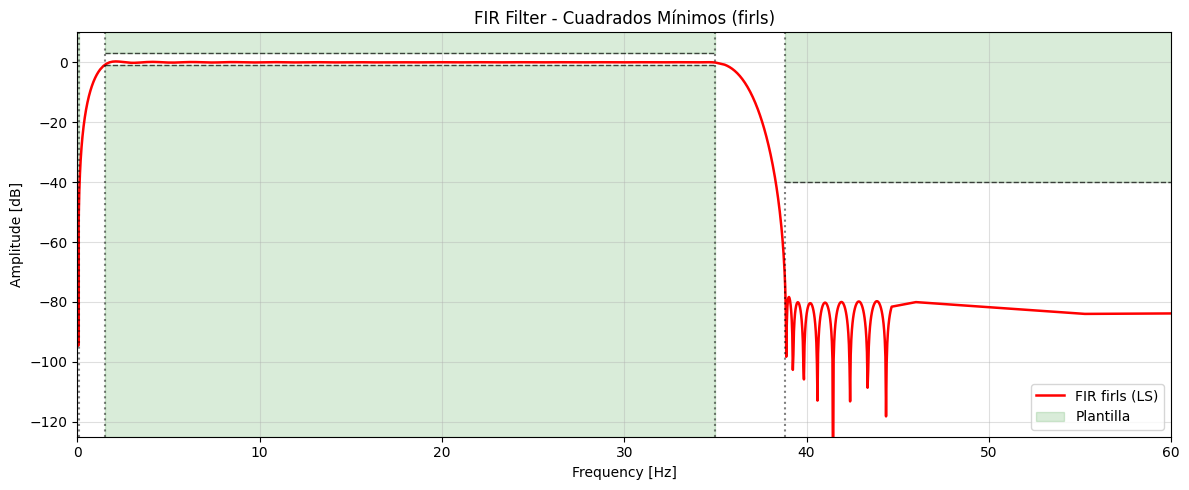

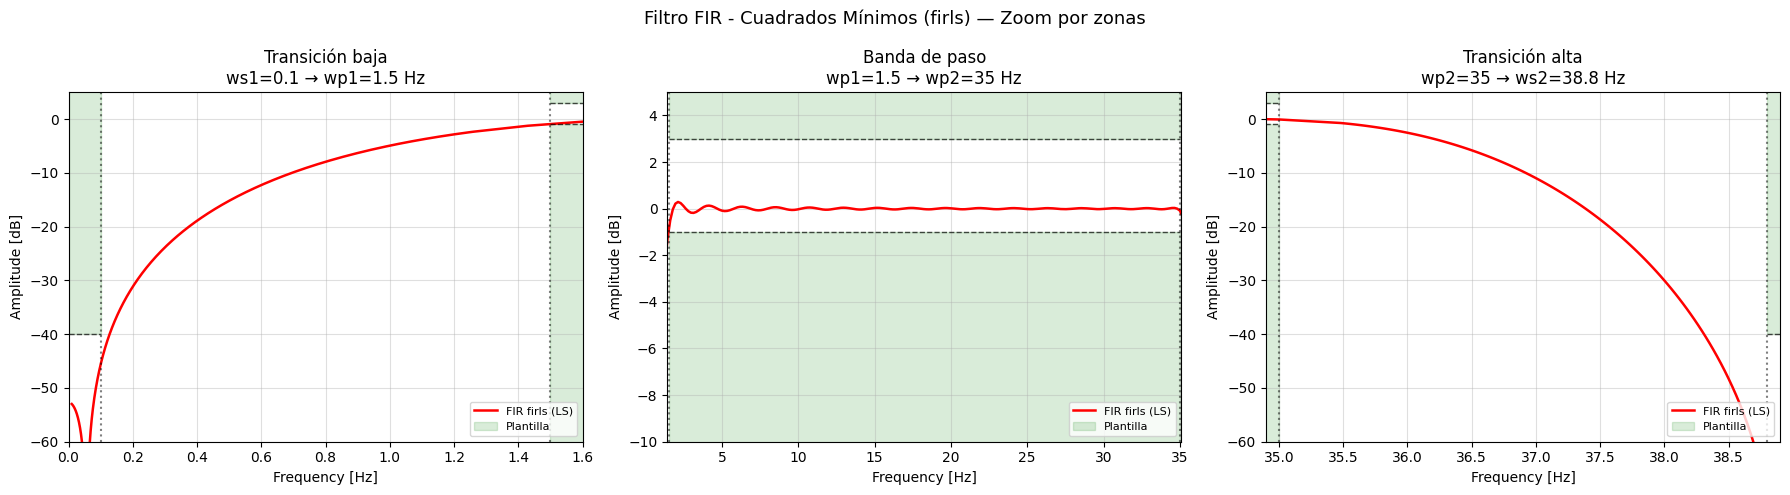

In [20]:
#%% Librerías
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

#----CUADRADOS MINIMOS-----
fs = 1000
gpass = 1     # Atenuación máxima permitida en banda de paso (dB)
gstop = 40    # Atenuación mínima requerida en banda de stop (dB)

ws1_cm = 0.1 
wp1_cm = 1.5 
wp2_cm = 35 
ws2_cm = 38.8 

numtaps_cm = 901

demora = (numtaps_cm - 1 ) //2 #division entera

ww = np.concat([np.logspace(start = -2,stop = 0.1, num = 500), 
               np.linspace(start=1.26,stop = 35, num = 200), 
               np.logspace(start = 1.55,stop = 1.65, num = 300),
               np.linspace(start= 46,stop = fs//2, num = 50)])

bands   = [0,    ws1_cm,   # banda de rechazo 1
           wp1_cm,  wp2_cm,   # banda de paso
           ws2_cm,  fs/2]  # banda de rechazo 2

desired = [0, 0,        # rechazo total en banda 1
           1, 1,        # paso unitario
           0, 0]        # rechazo total en banda 2

weight  = [100, 1, 100]   # más exigente en las bandas de rechazo

#es mas exigente el paso de ws1 a wp1 que el de wp2 a ws2
b_cm = sig.firls(numtaps_cm, bands, desired, weight = weight, fs=fs)

w_ls, h_ls = sig.freqz(b_cm, worN=ww, fs=fs)


#---------- Filtro FIR (CUADRADOS MINIMOS)-------------------
# =============================================================================
# BLOQUE DE PLOT - FIR CUADRADOS MÍNIMOS (firls)
# =============================================================================
fig, ax1 = plt.subplots(figsize=(12, 5), tight_layout=True)
ax1.set_title("FIR Filter - Cuadrados Mínimos (firls)")

# 1. Curva del filtro firls
ax1.plot(w_ls, 20 * np.log10(np.abs(h_ls)), 'r', linewidth=1.8, label='FIR firls (LS)')

# 2. Plantilla
piso_grafico  = -125
techo_grafico = 10              # 10 es más estándar que 40

# --- Banda de parada 1 ---
ax1.fill_between([0, ws1_cm],       -gstop, techo_grafico, color='green', alpha=0.15, label='Plantilla')
ax1.plot(        [0, ws1_cm],       [-gstop, -gstop],       'k--', linewidth=1, alpha=0.7)

# --- Banda de paso ---
ax1.fill_between([wp1_cm, wp2_cm],  piso_grafico, -gpass,   color='green', alpha=0.15)
ax1.plot(        [wp1_cm, wp2_cm],  [-gpass, -gpass],        'k--', linewidth=1, alpha=0.7)
ax1.fill_between([wp1_cm, wp2_cm],  3, techo_grafico,        color='green', alpha=0.15)
ax1.plot(        [wp1_cm, wp2_cm],  [3, 3],                  'k--', linewidth=1, alpha=0.7)

# --- Banda de parada 2 ---
ax1.fill_between([ws2_cm, fs/2],    -gstop, techo_grafico,  color='green', alpha=0.15)
ax1.plot(        [ws2_cm, fs/2],    [-gstop, -gstop],        'k--', linewidth=1, alpha=0.7)

# Líneas verticales con las variables correctas
ax1.axvline(ws1_cm, color='k', linestyle=':', alpha=0.5)
ax1.axvline(wp1_cm, color='k', linestyle=':', alpha=0.5)
ax1.axvline(wp2_cm, color='k', linestyle=':', alpha=0.5)
ax1.axvline(ws2_cm, color='k', linestyle=':', alpha=0.5)

ax1.set_ylabel('Amplitude [dB]')
ax1.set_xlabel('Frequency [Hz]')
ax1.set_xlim(0, 60)
ax1.set_ylim([piso_grafico, techo_grafico])
ax1.grid(True, which='both', linestyle='-', alpha=0.4)
ax1.legend(loc='lower right')
plt.show()

# =============================================================================
# BLOQUE DE PLOT - TRES SUBPLOTS CON ZOOM EN ZONAS DE INTERÉS
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5), tight_layout=True)
fig.suptitle("Filtro FIR - Cuadrados Mínimos (firls) — Zoom por zonas", fontsize=13)

# Margen visual alrededor de cada zona
margen = 0.1  # Hz

zonas = [
    # (ax,  xlim,                              ylim,               título)
    (axes[0], (ws1_cm - margen, wp1_cm + margen), (-60,  5),   f"Transición baja\nws1={ws1_cm} → wp1={wp1_cm} Hz"),
    (axes[1], (wp1_cm - margen, wp2_cm + margen), (-10,  5),   f"Banda de paso\nwp1={wp1_cm} → wp2={wp2_cm} Hz"),
    (axes[2], (wp2_cm - margen, ws2_cm + margen), (-60,  5),   f"Transición alta\nwp2={wp2_cm} → ws2={ws2_cm} Hz"),
]

for ax, xlim, ylim, titulo in zonas:
    # Curva del filtro
    ax.plot(w_ls, 20 * np.log10(np.abs(h_ls)), 'r', linewidth=1.8, label='FIR firls (LS)')

    # --- Plantilla: banda de stop 1 ---
    ax.fill_between([0, ws1_cm],      -gstop, techo_grafico, color='green', alpha=0.15, label='Plantilla')
    ax.plot(        [0, ws1_cm],      [-gstop, -gstop],       'k--', linewidth=1, alpha=0.7)

    # --- Plantilla: banda de paso ---
    ax.fill_between([wp1_cm, wp2_cm], piso_grafico, -gpass,  color='green', alpha=0.15)
    ax.plot(        [wp1_cm, wp2_cm], [-gpass, -gpass],       'k--', linewidth=1, alpha=0.7)
    ax.fill_between([wp1_cm, wp2_cm], 3, techo_grafico,       color='green', alpha=0.15)
    ax.plot(        [wp1_cm, wp2_cm], [3, 3],                 'k--', linewidth=1, alpha=0.7)

    # --- Plantilla: banda de stop 2 ---
    ax.fill_between([ws2_cm, fs/2],   -gstop, techo_grafico, color='green', alpha=0.15)
    ax.plot(        [ws2_cm, fs/2],   [-gstop, -gstop],       'k--', linewidth=1, alpha=0.7)

    # Líneas verticales de referencia
    for xv in [ws1_cm, wp1_cm, wp2_cm, ws2_cm]:
        ax.axvline(xv, color='k', linestyle=':', alpha=0.5)

    # Zoom y estética
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(titulo)
    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel('Amplitude [dB]')
    ax.grid(True, which='both', linestyle='-', alpha=0.4)
    ax.legend(loc='lower right', fontsize=8)

plt.show()




Observamos que la respuesta en frecuencia del filtro diseñado satisface la plantilla especificada en todas las bandas, teniendo en cuenta que la atenuación en las bandas de stop supera los 40 dB.

Ahora analizamos para este caso la señal del ECG

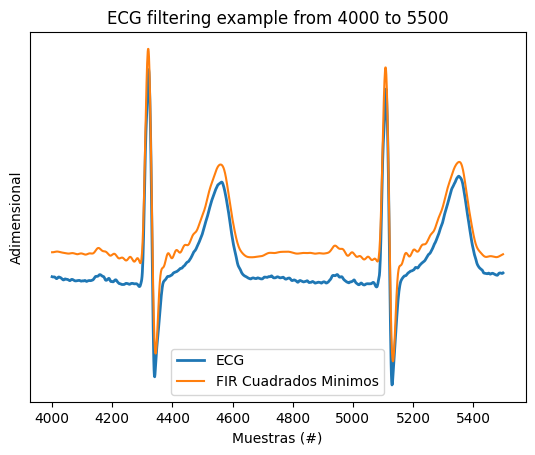

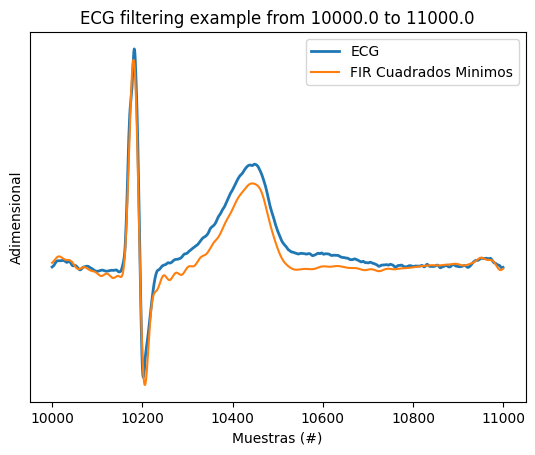

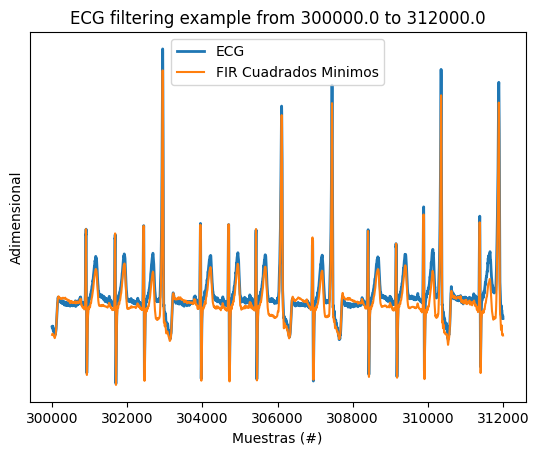

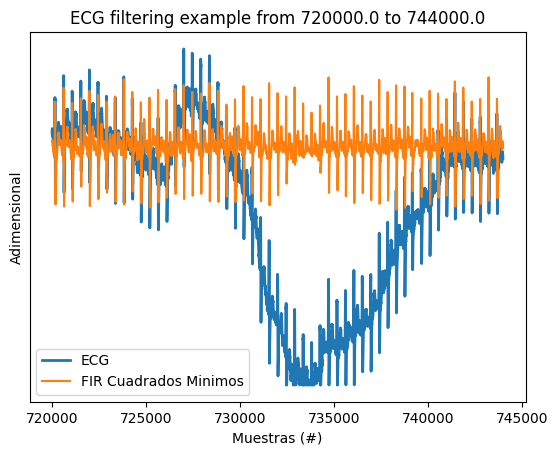

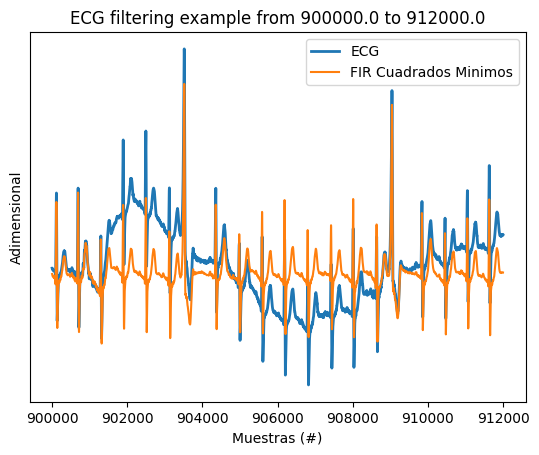

In [21]:
#%% PROCESAMIENTO DE SEÑAL DE ECG

##################
## ECG con ruido
##################

mat_struct = sio.loadmat(r'pdstestbench/ECG_TP4.mat')

ecg_one_lead = mat_struct['ecg_lead'].flatten() #lo aplanamos
cant_muestras = len(ecg_one_lead)

#Procesar ecg

ECG_f_cm = sig.lfilter(b_cm,1., ecg_one_lead)

###################################
#%% Regiones de interés sin ruido #
###################################
 
regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='int')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_cm[zoom_region + demora], label='FIR Cuadrados Minimos')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()
 
###################################
#%% Regiones de interés con ruido #
###################################
 
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_cm[zoom_region + demora], label='FIR Cuadrados Minimos')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()

Vemos que al procesar la señal de ECG se comprobó que el filtro preserva la morfología característica del complejo QRS, reduce la deriva de línea de base producida por componentes de muy baja frecuencia, y atenúa el ruido de alta frecuencia presente en la señal.

### Metodología de Parks-Mc Clellan-Remez

Para el caso del filtro FIR utilizando la metodología de Parks-Mc Clellan-Remez, fui tambien fui exigiendo la plantilla hasta obtener los parámetros que la cumplen, estos fueron $ ws1 = 0.1 Hz , ws2 = 38 Hz , wp1 = 1.2 Hz, wp2 = 36 Hz$ , utilizando una cantidad de numtaps = 901. Para este caso de filtro, tambien estuve modificando el "weight", donde impongo la prioridad de cada parte del filtro.

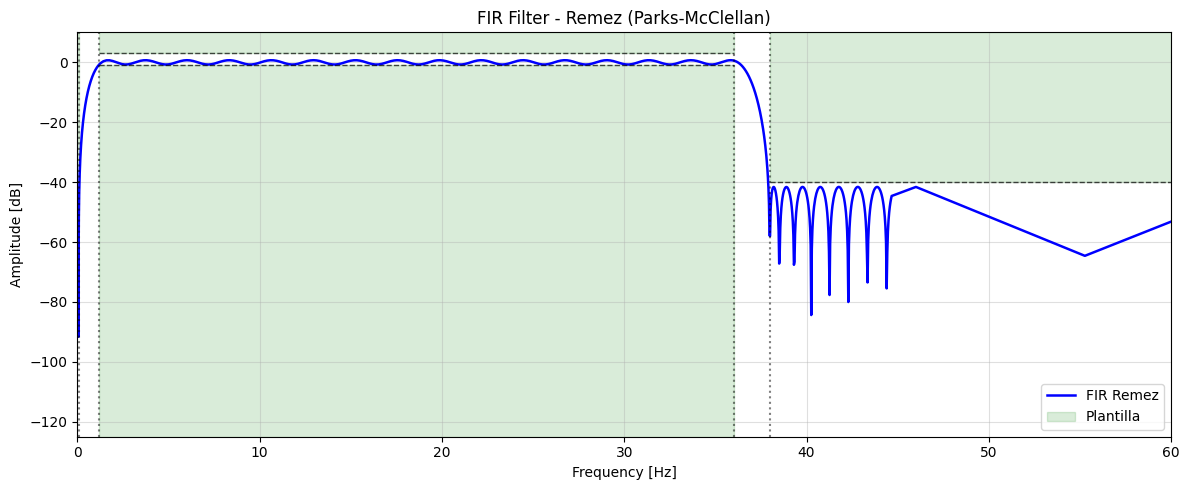

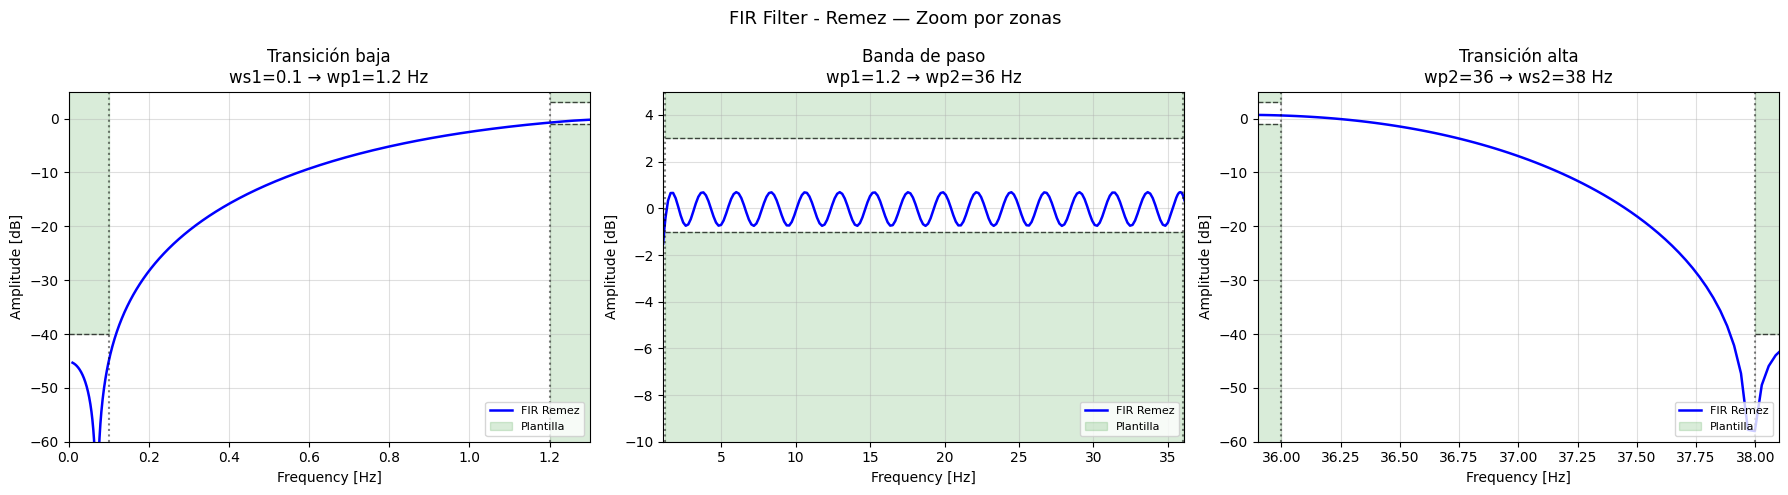

In [22]:
#%% Librerías
import numpy as np
import matplotlib.pyplot as plt

from scipy import signal as sig
import scipy.io as sio


ww = np.concatenate([
    np.logspace(start=-2,  stop=0.1,  num=500),
    np.linspace(start=1.26, stop=35,  num=200),
    np.logspace(start=1.55, stop=1.65, num=300),
    np.linspace(start=46,  stop=fs//2, num=50)
])
numtaps_remez = 901

ws1_p = 0.1
wp1_p = 1.2
wp2_p = 36
ws2_p = 38


bands_remez   = [0,    ws1_p,   # banda de rechazo 1
                 wp1_p,  wp2_p,   # banda de paso
                 ws2_p,  fs/2]  # banda de rechazo 2

desired_remez = [0, 1, 0]        # amplitud en banda de rechazo 1
                                 # amplitud en banda de paso
                                 # amplitud en banda de rechazo 2

weight_remez  = [15, 1, 10]     # igual criterio que firls, ajustar según resultado

b_remez = sig.remez(numtaps_remez, bands_remez, desired_remez,
                    weight=weight_remez, fs=fs)

w_remez, h_remez = sig.freqz(b_remez, worN=ww, fs=fs)

# =============================================================================
# BLOQUE DE PLOT - FIR REMEZ
# =============================================================================
fig, ax1 = plt.subplots(figsize=(12, 5), tight_layout=True)
ax1.set_title("FIR Filter - Remez (Parks-McClellan)")

ax1.plot(w_remez, 20 * np.log10(np.abs(h_remez)), 'b', linewidth=1.8, label='FIR Remez')

piso_grafico  = -125
techo_grafico = 10

# --- Banda de stop 1 ---
ax1.fill_between([0, ws1_p],       -gstop, techo_grafico, color='green', alpha=0.15, label='Plantilla')
ax1.plot(        [0, ws1_p],       [-gstop, -gstop],       'k--', linewidth=1, alpha=0.7)

# --- Banda de paso ---
ax1.fill_between([wp1_p, wp2_p],   piso_grafico, -gpass,   color='green', alpha=0.15)
ax1.plot(        [wp1_p, wp2_p],   [-gpass, -gpass],        'k--', linewidth=1, alpha=0.7)
ax1.fill_between([wp1_p, wp2_p],   3, techo_grafico,        color='green', alpha=0.15)
ax1.plot(        [wp1_p, wp2_p],   [3, 3],                  'k--', linewidth=1, alpha=0.7)

# --- Banda de stop 2 ---
ax1.fill_between([ws2_p, fs/2],    -gstop, techo_grafico,  color='green', alpha=0.15)
ax1.plot(        [ws2_p, fs/2],    [-gstop, -gstop],        'k--', linewidth=1, alpha=0.7)

ax1.axvline(ws1_p, color='k', linestyle=':', alpha=0.5)
ax1.axvline(wp1_p, color='k', linestyle=':', alpha=0.5)
ax1.axvline(wp2_p, color='k', linestyle=':', alpha=0.5)
ax1.axvline(ws2_p, color='k', linestyle=':', alpha=0.5)

ax1.set_ylabel('Amplitude [dB]')
ax1.set_xlabel('Frequency [Hz]')
ax1.set_xlim(0, 60)
ax1.set_ylim([piso_grafico, techo_grafico])
ax1.grid(True, which='both', linestyle='-', alpha=0.4)
ax1.legend(loc='lower right')
plt.show()

# =============================================================================
# BLOQUE DE PLOT - TRES SUBPLOTS CON ZOOM
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5), tight_layout=True)
fig.suptitle("FIR Filter - Remez — Zoom por zonas", fontsize=13)

margen = 0.1

zonas = [
    (axes[0], (ws1_p - margen, wp1_p + margen), (-60,  5), f"Transición baja\nws1={ws1_p} → wp1={wp1_p} Hz"),
    (axes[1], (wp1_p - margen, wp2_p + margen), (-10,  5), f"Banda de paso\nwp1={wp1_p} → wp2={wp2_p} Hz"),
    (axes[2], (wp2_p - margen, ws2_p + margen), (-60,  5), f"Transición alta\nwp2={wp2_p} → ws2={ws2_p} Hz"),
]

for ax, xlim, ylim, titulo in zonas:
    ax.plot(w_remez, 20 * np.log10(np.abs(h_remez)), 'b', linewidth=1.8, label='FIR Remez')

    ax.fill_between([0, ws1_p],      -gstop, techo_grafico, color='green', alpha=0.15, label='Plantilla')
    ax.plot(        [0, ws1_p],      [-gstop, -gstop],       'k--', linewidth=1, alpha=0.7)

    ax.fill_between([wp1_p, wp2_p],  piso_grafico, -gpass,  color='green', alpha=0.15)
    ax.plot(        [wp1_p, wp2_p],  [-gpass, -gpass],       'k--', linewidth=1, alpha=0.7)
    ax.fill_between([wp1_p, wp2_p],  3, techo_grafico,       color='green', alpha=0.15)
    ax.plot(        [wp1_p, wp2_p],  [3, 3],                 'k--', linewidth=1, alpha=0.7)

    ax.fill_between([ws2_p, fs/2],   -gstop, techo_grafico, color='green', alpha=0.15)
    ax.plot(        [ws2_p, fs/2],   [-gstop, -gstop],       'k--', linewidth=1, alpha=0.7)

    for xv in [ws1_p, wp1_p, wp2_p, ws2_p]:
        ax.axvline(xv, color='k', linestyle=':', alpha=0.5)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(titulo)
    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel('Amplitude [dB]')
    ax.grid(True, which='both', linestyle='-', alpha=0.4)
    ax.legend(loc='lower right', fontsize=8)

plt.show()

Vemos tambien en este caso que la respuesta en frecuencia del filtro diseñado satisface la plantilla especificada en todas las bandas, teniendo en cuenta que la atenuación en las bandas de stop supera los 40 dB.

Por ultimo, analizamos la señal del ECG con este filtro

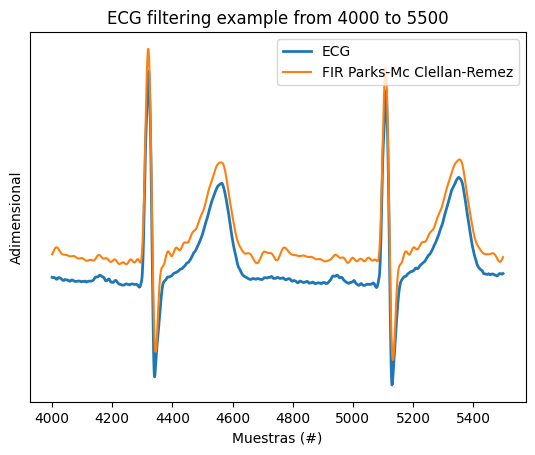

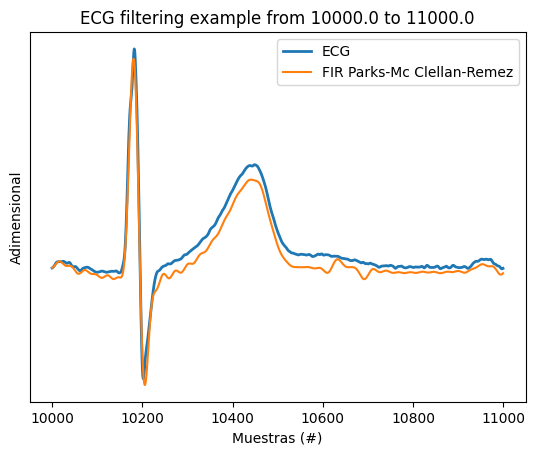

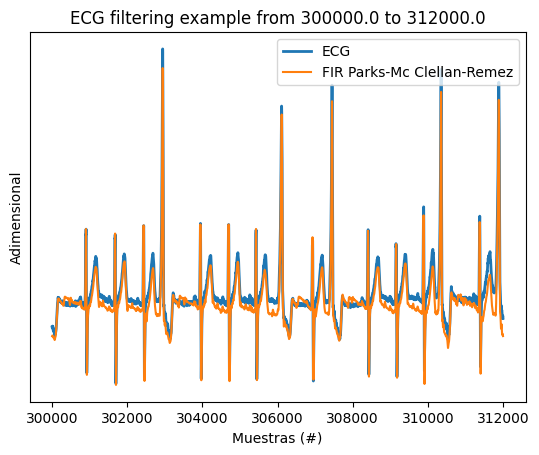

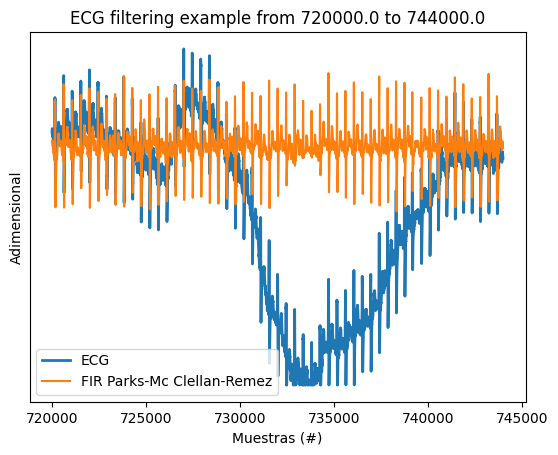

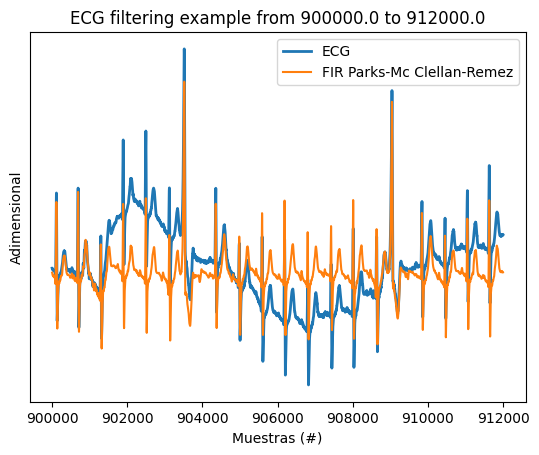

In [23]:
#%% PROCESAMIENTO DE SEÑAL DE ECG

##################
## ECG con ruido
##################

mat_struct = sio.loadmat(r'pdstestbench/ECG_TP4.mat')

ecg_one_lead = mat_struct['ecg_lead'].flatten() #lo aplanamos
cant_muestras = len(ecg_one_lead)

#Procesar ecg


ECG_f_remez = sig.lfilter(b_remez,1., ecg_one_lead)

###################################
#%% Regiones de interés sin ruido #
###################################
 
regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='int')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_remez[zoom_region + demora], label='FIR Parks-Mc Clellan-Remez')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()
 
###################################
#%% Regiones de interés con ruido #
###################################
 
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_remez[zoom_region + demora], label='FIR Parks-Mc Clellan-Remez')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()


Finalmente vemos para este último caso que se cumple la funcion del filtro donde mantiene las características del complejo QRS, reduce la deriva de línea de base producida por componentes de muy baja frecuencia, y atenúa el ruido de alta frecuencia presente en la señal.